In [ ]:
from viz import *


<a id="experiment-1"></a>
# Experiment #1


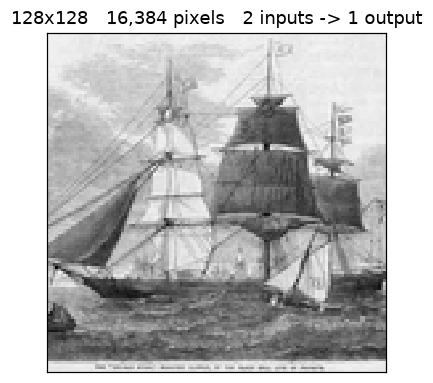

In [ ]:
target(128)


We are going to create a neural network that can predict this.

We will be taking $x, y$ values as input and outputting brightness.

$$(x,\ y) \;\longrightarrow\; \text{network} \;\longrightarrow\; \text{brightness}$$

Two numbers in, one number out. The network never sees the picture — only one
pixel's coordinates at a time, and how bright that pixel should be. If it can
learn that mapping, the image comes back.

Every pixel is one training example, so a $128 \times 128$ image gives
**16,384 examples**.


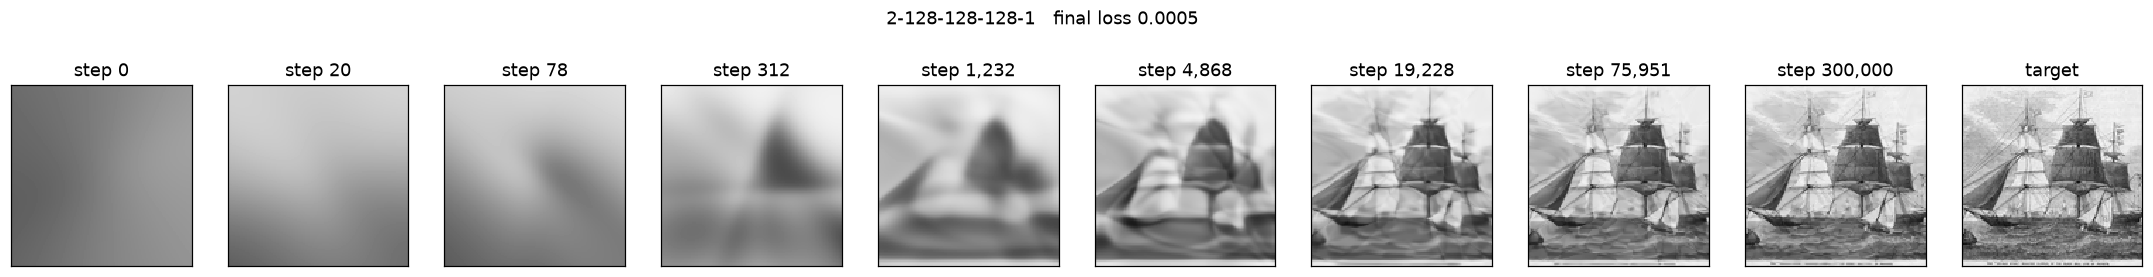

In [ ]:
learn_image(steps=300_000, frames=9)


The network starts as a flat grey field — a random function of two numbers, with
no idea a ship exists. Then, in order: **the horizon, the dark mass of the
mainsail, the hull, the individual sails, and finally the rigging.**

It learns the picture from low frequencies upward. Big smooth shapes are cheap;
fine detail is expensive and arrives last — but it does arrive.

There is no wall here, only a price. Getting from *recognisable ship* to *near
copy* cost 25× more steps than getting to recognisable in the first place.


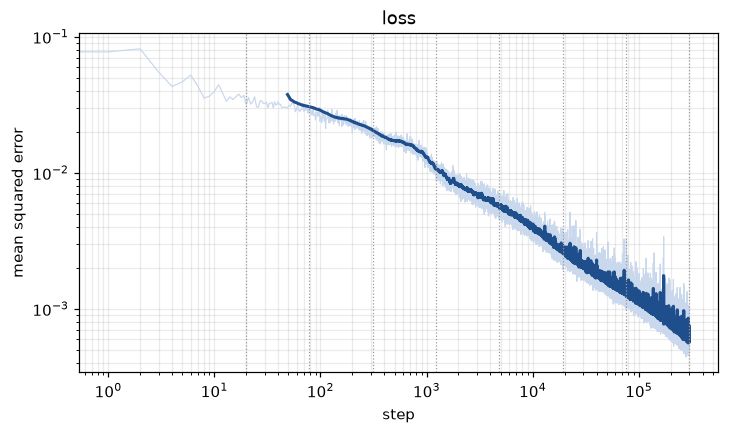

In [ ]:
loss_chart()


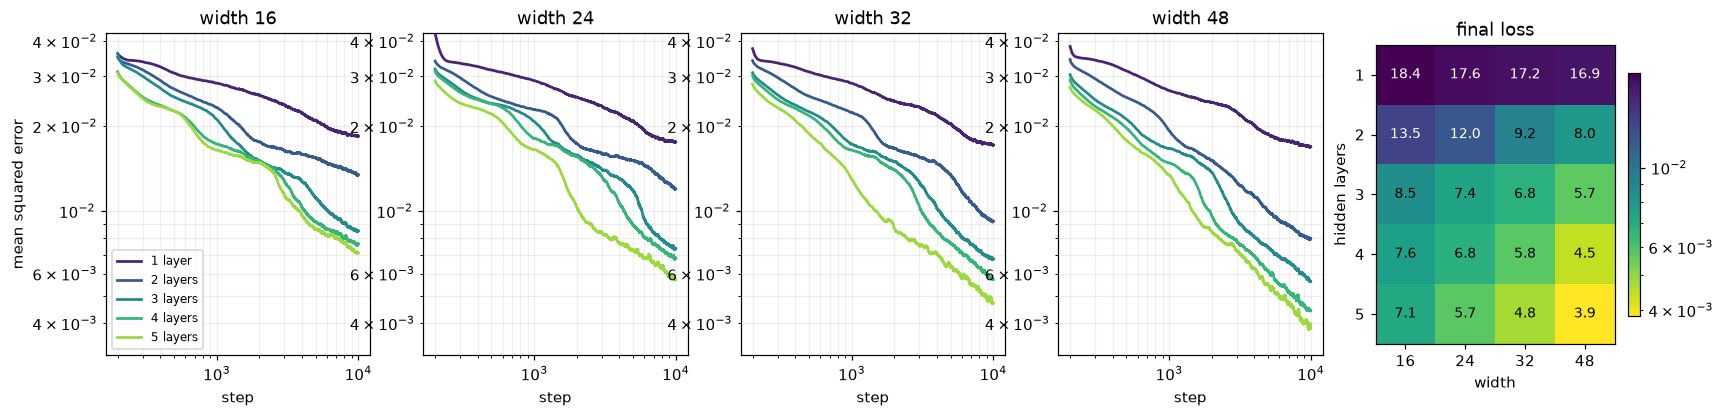

In [ ]:
runs = arch_sweep(steps=10_000)   # 20 shapes, none with more parameters than pixels
show_sweep(runs)


Now hold the budget **fixed** at 8,192 parameters — exactly half the pixel count,
so every network must compress 2:1 — and spend it differently. One hidden layer
gets 2,048 neurons; ten layers get 29 each.

The dashed line is a deliberate saboteur: same budget, but everything is forced
through three width-2 layers first.


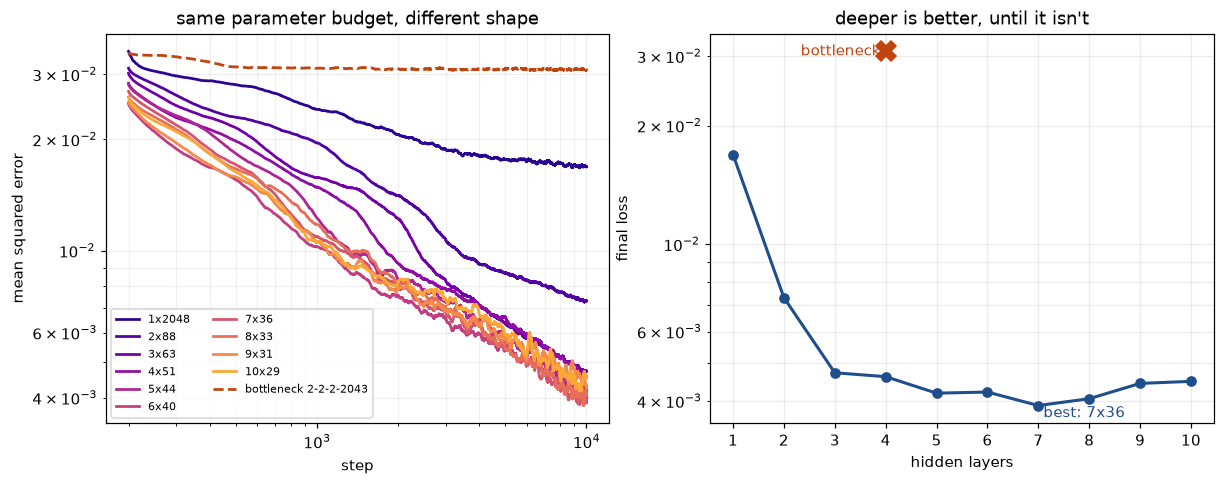

In [ ]:
show_budget(budget_sweep(steps=10_000))   # 8,192 params every time, shape varies


Same 8,192 numbers every time. The results span **8×**.

- **One wide layer is the worst honest shape** — 2,048 neurons, 4.3× worse than
  the best, and already stalling by 10,000 steps. A single layer can only add
  bumps together; it has no way to build on its own work.
- **Depth pays quickly, then stops.** Most of the gain is in the first three
  layers. From 3 to 8 everything sits within 20% of best, and past 8 it drifts
  back up. The optimum is a broad basin, not a knife edge.
- **The saboteur is the point.** Identical parameter count, 7.9× worse, and its
  curve is nearly flat — it stopped learning around step 200. Once the image has
  been squeezed into two numbers, nothing downstream can recover it.

So parameter count is not capacity. **The narrowest layer is the ceiling**, and
everything spent after it is spent on what survived.
